### Implemtation TIBs Bars 

Tick imbalance bars 

$$
T*= \arg \min_{T} ( \theta_T \ge (E_0[T](2P(b_t=1)-1)) 
$$

- T* last index fisnish bar
- $\arg\min$ condition
- $\theta_T$ fact imbalance
- $E_0[T]$ expected size var 
- $(2P(b_t=1)-1)$ media movil de las bars anteriores para bt

$$
E_0[T]=(1-\lambda)T_{i-1} + \lambda E_0[T]_{i-1}
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [2]:
from pathlib import Path
import sys

cwd = Path().resolve()
for p in [cwd] + list(cwd.parents):
    if (p / "utils").is_dir():
        sys.path.insert(0, str(p))
        break

from utils.download_data_binance import DowloadDataBinance


In [3]:
data_path = '../data/raw'
dowload_data = DowloadDataBinance(data_path)

df = dowload_data.download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  
    max_trades=300000
)

dowload_data.show_info(df)

Descargando trades de BTCUSDT...
Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
Guardado en: ../data/rawBTCUSDT_trades_20251025_154338.csv

INFORMACIÓN DE LOS DATOS
Total trades: 92,475
Período: 2025-10-20 20:41:56.518000 a 2025-10-21 03:19:50.691000
Duración: 6.6 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-20 20:41:56.518  111035.36   0.00007      7.772475
1 2025-10-20 20:41:56.729  111035.35   0.00087     96.600755
2 2025-10-20 20:41:57.328  111035.35   0.00058     64.400503
3 2025-10-20 20:41:57.891  111035.36   0.00021     23.317426
4 2025-10-20 20:41:57.906  111035.35   0.00007      7.772474

Estadísticas:
                           timestamp          price      quantity  \
count                          92475   92475.000000  92475.000000   
mean   2025-10-21 00:17:07.833193728  110273.088126      0.017201   
min       2025-10-20 20:41:56.518000  109303.860000      0.000010   
25%       2025-10-20 22:31:05.576000  109

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92475 entries, 0 to 92474
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     92475 non-null  datetime64[ns]
 1   price         92475 non-null  float64       
 2   quantity      92475 non-null  float64       
 3   dollar_value  92475 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 2.8 MB


In [5]:
df.head(5)

,timestamp,price,quantity,dollar_value
0,2025-10-20 20:41:56.518,111035.36,0.00007,7.772475
1,2025-10-20 20:41:56.729,111035.35,0.00087,96.600755
2,2025-10-20 20:41:57.328,111035.35,0.00058,64.400503
3,2025-10-20 20:41:57.891,111035.36,0.00021,23.317426
4,2025-10-20 20:41:57.906,111035.35,0.00007,7.772474


In [6]:
# get ticket directions 

def update_prob_buy(bar_b_t, current_prob, lambda_):
    recent_prob = (bar_b_t == 1).mean()
    # Suavizado exponencial doble para mayor estabilidad
    return (1 - lambda_**2) * recent_prob + lambda_**2 * current_prob


def get_tick_directions(df: pd.DataFrame) -> pd.Series:
    price_diff = df['price'].diff() # firence previus and acutal price
    b_t = np.sign(price_diff) # get a sign 
    
    b_t = b_t.replace(0, np.nan).ffill().fillna(1) # 0 -> Nan, fill series valid value, first (1)
    return b_t

def tick_imbalance_bars(
    df: pd.DataFrame, exp_lambda = 0.9, init_exp_T = 1600, init_p_buy=0.5) -> pd.DataFrame:
    df = df.copy()
    df['b_t'] = get_tick_directions(df)
    
    # initial 
    E_T = init_exp_T
    prob_buy = init_p_buy
    bars = []
    tick_imbalance = 0
    tick_count = 0 
    last_index = 0 
    
    for i in range(1, len(df)):
        tick_count += 1
        tick_imbalance += df.loc[i, 'b_t'] 
        
        # stop condition 
        thereshold = E_T * abs(2 * prob_buy - 1) 
        # Añade un mínimo de ticks para evitar barras muy cortas
        MIN_TICKS = 20
        if abs(tick_imbalance) >= thereshold and tick_count >= MIN_TICKS:
            # Formar barra
            bar = df.iloc[last_index:i+1]
            bars.append({
                'open_time': bar['timestamp'].iloc[0],
                'close_time': bar['timestamp'].iloc[-1],
                'open': bar['price'].iloc[0],
                'high': bar['price'].max(),
                'low': bar['price'].min(),
                'close': bar['price'].iloc[-1],
                'n_ticks': len(bar),
                'volume': bar['quantity'].sum(),
                'dollar_value': bar['dollar_value'].sum(),
            })
            
            # update waited 
            E_T =(1 - exp_lambda) * len(bar) + exp_lambda * E_T 
            prob_buy = update_prob_buy(bar['b_t'], prob_buy, exp_lambda)

            
            # Reset
            tick_imbalance = 0 
            tick_count = 0 
            last_index = i + 1
    
    bars_df = pd.DataFrame(bars)    
    return bars_df

In [7]:
tib_bars = tick_imbalance_bars(df)
print(tib_bars.head(5).sort_index())


                open_time              close_time       open       high  \
0 2025-10-20 20:41:56.518 2025-10-20 20:42:00.023  111035.36  111040.92   
1 2025-10-20 20:42:00.026 2025-10-20 20:50:22.725  111041.52  111136.54   
2 2025-10-20 20:50:22.819 2025-10-20 21:02:16.194  111005.30  111122.53   
3 2025-10-20 21:02:16.653 2025-10-20 21:03:40.023  111098.23  111122.53   
4 2025-10-20 21:03:40.218 2025-10-20 21:08:07.640  111122.52  111152.01   

         low      close  n_ticks    volume  dollar_value  
0  111035.35  111040.92       21   0.28112  3.121517e+04  
1  110995.92  111005.30     1752  26.11920  2.900908e+06  
2  110950.87  111098.23     2566  20.47657  2.273488e+06  
3  111098.22  111122.53      306   0.99758  1.108433e+05  
4  111089.90  111152.01     1093   7.69617  8.552116e+05  


In [8]:
print('num bars:',len(tib_bars))

num bars: 63


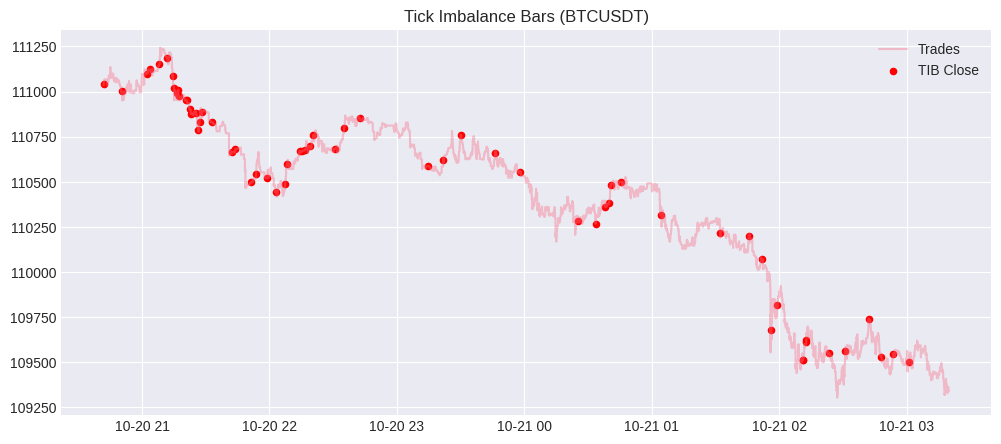

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['price'], alpha=0.4, label='Trades')
plt.scatter(tib_bars['close_time'], tib_bars['close'], color='red', s=20, label='TIB Close')
plt.legend()
plt.title('Tick Imbalance Bars (BTCUSDT)')
plt.show()


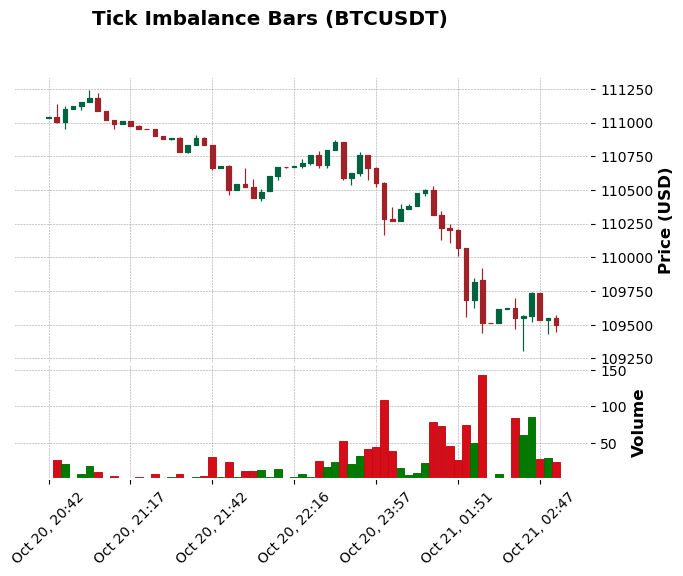

In [10]:
import mplfinance as mpf

tib_bars.set_index('close_time', inplace=True)

mpf.plot(
    tib_bars,
    type='candle',
    style='charles',
    volume=True,
    title='Tick Imbalance Bars (BTCUSDT)',
    ylabel='Price (USD)',
    ylabel_lower='Volume',
)
